# Identification de chiffres sur une image

In [ ]:
# Bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## Import des données

5


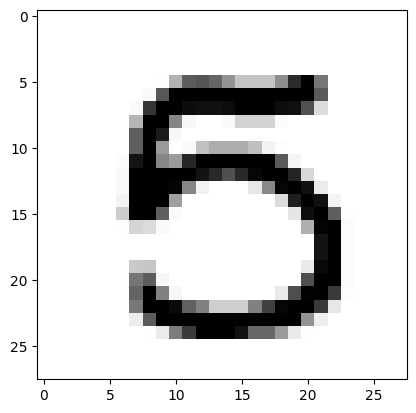

In [35]:
# Téléchargement des données
(X_train_data, Y_train_data), (X_test_data, Y_test_data) = mnist.load_data()
N = X_train_data.shape[0]  # N = 60 000 données

# Affichage d'une image aléatoire
i = np.random.randint(0, len(X_train_data))
print(Y_train_data[i])
plt.imshow(X_train_data[i], cmap="Greys")
plt.show()

In [37]:
# Données d'apprentissage X
X_train = np.reshape(X_train_data,(N,784)) # vecteur image
X_train = X_train/255 # normalisation
# Données d'apprentissage Y vers une liste de taille 10
Y_train = to_categorical(Y_train_data, num_classes=10)
# Données de test
X_test = np.reshape(X_test_data,(X_test_data.shape[0],784))
X_test = X_test/255
Y_test = to_categorical(Y_test_data, num_classes=10)



### Partie B - Le réseau de neurones
p = 8
modele = Sequential()

# Première couche : p neurones (entrée de dimension 784 = 28x28)
modele.add(Dense(p, input_dim=784, activation="sigmoid"))

# Deuxième couche : p neurones
modele.add(Dense(p, activation="sigmoid"))

# Couche de sortie : 1O neurones (un par chiffre)
modele.add(Dense(10, activation="softmax"))

# Choix de la méthode de descente de gradient
modele.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
print(modele.summary())

### Partie C - Calcul des poids par descente de gradient
modele.fit(X_train, Y_train, batch_size=32, epochs=40)

### Partie D - Résultats
resultat = modele.evaluate(X_test, Y_test, verbose=0)
print("Valeur de l" "erreur sur les données de test (loss):", resultat[0])
print("Précision sur les données de test (accuracy):", resultat[1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │         6,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,442 (25.16 KB)

 Trainable params: 6,442 (25.16 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.1508 - loss: 2.3039
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3898 - loss: 2.1883
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4598 - loss: 1.9892
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4904 - loss: 1.7342
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5274 - loss: 1.5334
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5990 - loss: 1.3842
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6803 - loss: 1.2575
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7318 - loss: 1.1356
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7648 - loss: 1.0289
Epoch 10/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7838 - loss: 0.9384
Epoch 11/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7972 - loss: 0.8594
Epoch 12/40
1875/1875 ━━━